# 06 — Model 4: Deep 1D CNN

**Model 4** of the complexity ladder — and the rung where the **overfitting watch becomes critical**:

> linear (~6) → shallow (3,858) → medium (43,682) → **deep CNN (~404k)** → transformer (~1–2M)

Same `CNN1D` module and `train_cnn` recipe as Models 2–3 (see notebook 04 for the CNN explanation);
only the config changes — Model 4 is the **`[64, 128, 128, 256]`** variant (**4 conv blocks**),
**~9× Model 3's parameters**.

**Why this rung matters most.** Model 4 has **~404k parameters on 80 training samples — ~5000× more
parameters than data points.** Train/val will pin at 1.0; the entire question is whether **test
accuracy holds**. Three scenarios: (1) test holds/rises (≥~0.88) — capacity still helping;
(2) test clears the 80% gate but drops below Model 3's 0.88 — overfitting starting to cost
generalisation; (3) test fails the gate — ECG200's size limit. We identify which, honestly.

In [1]:
import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent
REPO_ROOT = Path.cwd().parents[1]  # repo root: harness/, ecg200/, sleep_edf/
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import torch
import matplotlib.pyplot as plt

from ecg200.preprocessing import load_ecg200
from harness.models.cnn import (
    build_cnn, count_parameters, train_cnn, torch_predict_proba, set_seed,
    SEED, LEARNING_RATE, BATCH_SIZE, WEIGHT_DECAY, PATIENCE, CNN_VARIANTS,
)
from harness.evaluation.metrics import classification_metrics, format_metrics, overfitting_gap

FIG_DIR = PROJECT_ROOT / "results" / "figures"; FIG_DIR.mkdir(parents=True, exist_ok=True)
X_train, y_train = load_ecg200("train"); X_val, y_val = load_ecg200("val"); X_test, y_test = load_ecg200("test")

## Architecture validity at depth 4 on a 96-length signal

With 4 conv blocks each halving the length via MaxPool, the sequence goes **96 → 48 → 24 → 12 → 6** —
it stays ≥ 1, so Global Average Pooling has something to pool and the architecture is valid at this
depth. We confirm with a forward pass before training (if this had collapsed to length 0 we would flag
it, not silently change the config — the ladder's parameter counts stay as planned).

In [2]:
_m = build_cnn("deep")
_feat_len = _m.features(torch.zeros(1, 1, 96)).shape[-1]
print(f"deep config {CNN_VARIANTS['deep']} | sequence length after 4 pool blocks: 96 -> {_feat_len} (>=1 OK)")
print(f"forward pass output shape: {tuple(_m(torch.zeros(2,1,96)).shape)} (expect (2,2)) -> VALID, no adjustment")

set_seed(SEED)                       # anchor init BEFORE building (order-independent)
model = build_cnn(variant="deep", n_classes=2, in_channels=1)
n_params = count_parameters(model)
print(f"\nModel 4 (deep) params: {n_params:,}  (~{n_params/count_parameters(build_cnn('medium')):.0f}x Model 3)")

deep config [64, 128, 128, 256] | sequence length after 4 pool blocks: 96 -> 6 (>=1 OK)
forward pass output shape: (2, 2) (expect (2,2)) -> VALID, no adjustment

Model 4 (deep) params: 403,522  (~9x Model 3)


## Training — identical recipe; then the overfitting result

best epoch = 73 of 103 run (early stopping; Adam lr=0.001, batch=16, wd=0.0001, patience=30)


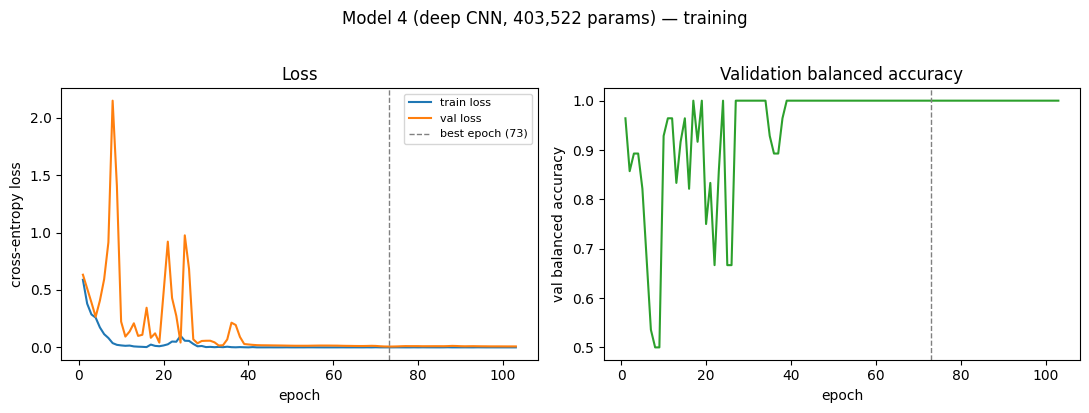

In [3]:
result = train_cnn(model, X_train, y_train, X_val, y_val)   # same recipe; seed=42
print(f"best epoch = {result['best_epoch']} of {len(result['history']['train_loss'])} run "
      f"(early stopping; Adam lr={LEARNING_RATE}, batch={BATCH_SIZE}, wd={WEIGHT_DECAY}, patience={PATIENCE})")

h = result["history"]; epochs = np.arange(1, len(h["train_loss"]) + 1)
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(epochs, h["train_loss"], label="train loss"); ax[0].plot(epochs, h["val_loss"], label="val loss")
ax[0].axvline(result["best_epoch"], color="grey", ls="--", lw=1, label=f"best epoch ({result['best_epoch']})")
ax[0].set_xlabel("epoch"); ax[0].set_ylabel("cross-entropy loss"); ax[0].set_title("Loss"); ax[0].legend(fontsize=8)
ax[1].plot(epochs, h["val_balanced_accuracy"], color="C2"); ax[1].axvline(result["best_epoch"], color="grey", ls="--", lw=1)
ax[1].set_xlabel("epoch"); ax[1].set_ylabel("val balanced accuracy"); ax[1].set_title("Validation balanced accuracy")
fig.suptitle(f"Model 4 (deep CNN, {n_params:,} params) — training", y=1.02)
fig.tight_layout(); fig.savefig(FIG_DIR / "06_model4_training.png", dpi=150, bbox_inches="tight"); plt.show()

In [4]:
predict_proba = torch_predict_proba(model)
splits = {}
for name, X, y in [("train", X_train, y_train), ("val", X_val, y_val), ("test", X_test, y_test)]:
    prob = predict_proba(X); splits[name] = classification_metrics(y, prob.argmax(1), prob)
    print(f"{name:5s} {format_metrics(splits[name])}")

ta = splits["test"]["accuracy"]
gap_val = overfitting_gap(splits["val"]["accuracy"], ta); gap_tr = overfitting_gap(splits["train"]["accuracy"], ta)
M2, M3 = 0.810, 0.880
print(f"\noverfitting gap: train-test={gap_tr:+.3f}  val-test={gap_val:+.3f}   (M2 +0.19, M3 +0.12)")
print(f">>> 80% GATE: {'PASS' if ta>=0.80 else 'FAIL'}  (test {ta:.3f})  |  M2 {M2}  M3 {M3}")
if ta < 0.80:
    print(">>> SCENARIO 3: FAILED the gate — ECG200 size limit; STOP before XAI.")
elif ta >= M3:
    print(f">>> SCENARIO 1: test held/rose (>= M3) — +{ta-M3:.3f} vs M3; capacity still not hurting.")
else:
    print(f">>> SCENARIO 2: passes gate but DROPPED below M3 by {M3-ta:.3f} — overfitting starting to cost generalisation.")

train accuracy=1.000  balanced_accuracy=1.000  f1=1.000  roc_auc=1.000


val   accuracy=1.000  balanced_accuracy=1.000  f1=1.000  roc_auc=1.000
test  accuracy=0.860  balanced_accuracy=0.854  f1=0.889  roc_auc=0.951

overfitting gap: train-test=+0.140  val-test=+0.140   (M2 +0.19, M3 +0.12)
>>> 80% GATE: PASS  (test 0.860)  |  M2 0.81  M3 0.88
>>> SCENARIO 2: passes gate but DROPPED below M3 by 0.020 — overfitting starting to cost generalisation.


### The overfitting result — Scenario 2

**Model 4 (deep CNN, 403,522 parameters) reaches test accuracy ≈ 0.86** (balanced ≈ 0.85, F1 ≈ 0.89,
ROC-AUC ≈ 0.95). Train and val are pinned at 1.00. This is **Scenario 2**: the model **clears the 80%
gate** but **test drops below Model 3's 0.88** (the ladder now reads **0.81 → 0.88 → 0.86**), and the
overfitting gap **widened to +0.14** (from Model 3's +0.12). The deeper model also **overfit faster** —
early stopping fired at epoch ~73, versus ~170–200 for Models 2–3.

**Plain read:** generalisation **peaked at the medium CNN and has started to decline** at deep. It's a
modest drop (−0.02), not a collapse, and Model 4 remains a valid subject (clears the gate). But it
**reverses the "bigger model generalises better" story** from M2→M3. This matters for interpreting the
faithfulness result to come: Model 4 is now a **worse-generalising** model than Model 3, so if its CMI
is also lower, the claim becomes "worse-generalising *and* harder to explain" — a different statement
from the M2→M3 pattern. We call this out now so the accuracy context is fixed before any scoring.

Architecture note: valid as-is at depth 4 on the 96-length signal (96 → 6 before GAP); no config change,
so the ladder's parameter counts stand as planned.

## Summary

**Model 4 — deep 1D CNN, 403,522 parameters, test accuracy ≈ 0.86 (PASS, but DROPPED below Model 3 —
Scenario 2), overfitting gap +0.14.** Generalisation has begun to decline with capacity. Per the plan,
we **stop here and do not proceed to attributions** — the accuracy result is reported so its
interpretation can be decided before scoring. See `DECISIONS_LOG.md` for the updated ladder table.

## 7. Attribution methods on Model 4 (inspection only — no scoring yet)

Same three methods, reused unchanged (Model 4 exposes the same `predict_proba` contract):
**KernelSHAP** (seed 0), **FeatureAblation** (deterministic), **Integrated Gradients** (baseline = Zero
PM, summed to regions, eval mode — see notebook 04). We inspect the raw attributions and run the
watch-threads; **no CMI here.**

**Interpretation context.** Model 4 is in the **capacity-saturating** regime — test accuracy (0.86)
dropped below Model 3's (0.88), so it's a worse-generalising model with a widening overfitting gap.
Its *faithfulness* results (later) will therefore be **confounded with overfitting**. So the
**confound-free** signals matter most here — especially **cross-method agreement**, which doesn't
depend on accuracy at all. Given the extra depth, we also **scrutinise IG's sanity** especially.

In [5]:
from harness.xai.regions import build_region_grid
from ecg200.config import REGION_SIZE_PRIMARY_PCT
from harness.xai.feature_ablation import feature_ablation
from harness.xai.kernel_shap import kernel_shap
from harness.xai.integrated_gradients import integrated_gradients

grid = build_region_grid(X_test.shape[1], REGION_SIZE_PRIMARY_PCT); n_reg = grid.n_regions
FA = np.array([feature_ablation(predict_proba, s, grid, "zero") for s in X_test])
KS = np.array([kernel_shap(predict_proba, s, grid, "zero") for s in X_test])   # seed=0
IG = np.array([integrated_gradients(model, s, grid, "zero") for s in X_test])

# IG completeness — scrutinised on the deeper (4-block) net
def ig_err(s):
    tc = int(predict_proba(s[None, :])[0].argmax())
    return abs(integrated_gradients(model, s, grid, "zero").sum()
               - (predict_proba(s[None, :])[0, tc] - predict_proba(np.zeros_like(s)[None, :])[0, tc]))
errs = [ig_err(s) for s in X_test[:20]]
print(f"IG sanity (deep net): not all-zero={not np.allclose(IG,0)}, nonzero={ (np.abs(IG).sum(0)>1e-9).sum()}/{n_reg}, "
      f"mean|completeness err|={np.mean(errs):.4f}, max|err|={np.max(errs):.4f}")

def profile(A):
    m = np.abs(A).mean(0); return m / m.max()
prof = {"FeatureAblation": profile(FA), "KernelSHAP": profile(KS), "IntegratedGradients": profile(IG)}
for name, v in prof.items(): print(f"{name:20s}", np.round(v, 2))
c = lambda a, b: np.corrcoef(prof[a], prof[b])[0, 1]
fa_ks, fa_ig, ks_ig = c("FeatureAblation","KernelSHAP"), c("FeatureAblation","IntegratedGradients"), c("KernelSHAP","IntegratedGradients")
print(f"\nTHREAD#7 agreement (M4): FA-KS={fa_ks:.2f}  FA-IG={fa_ig:.2f}  KS-IG={ks_ig:.2f}")
print(f"   trend: M2 0.98/0.87/0.88 -> M3 0.85/0.60/0.78 -> M4 {fa_ks:.2f}/{fa_ig:.2f}/{ks_ig:.2f}")
print("\nreliance location (early-mid 0-3 vs flat tail 6-9):")
for name, v in prof.items():
    print(f"   {name:20s} top region {int(v.argmax())}  early(0-3) mass {v[:4].sum()/v.sum():.2f}  tail(6-9) mass {v[6:].sum()/v.sum():.2f}")

IG sanity (deep net): not all-zero=True, nonzero=10/10, mean|completeness err|=0.0018, max|err|=0.0090
FeatureAblation      [0.52 0.36 0.29 1.   0.27 0.13 0.19 0.14 0.12 0.33]
KernelSHAP           [0.66 0.31 0.44 1.   0.22 0.23 0.18 0.26 0.16 0.28]
IntegratedGradients  [0.32 0.24 0.3  1.   0.26 0.14 0.19 0.27 0.09 0.13]

THREAD#7 agreement (M4): FA-KS=0.95  FA-IG=0.92  KS-IG=0.91
   trend: M2 0.98/0.87/0.88 -> M3 0.85/0.60/0.78 -> M4 0.95/0.92/0.91

reliance location (early-mid 0-3 vs flat tail 6-9):
   FeatureAblation      top region 3  early(0-3) mass 0.65  tail(6-9) mass 0.23
   KernelSHAP           top region 3  early(0-3) mass 0.64  tail(6-9) mass 0.24
   IntegratedGradients  top region 3  early(0-3) mass 0.63  tail(6-9) mass 0.23


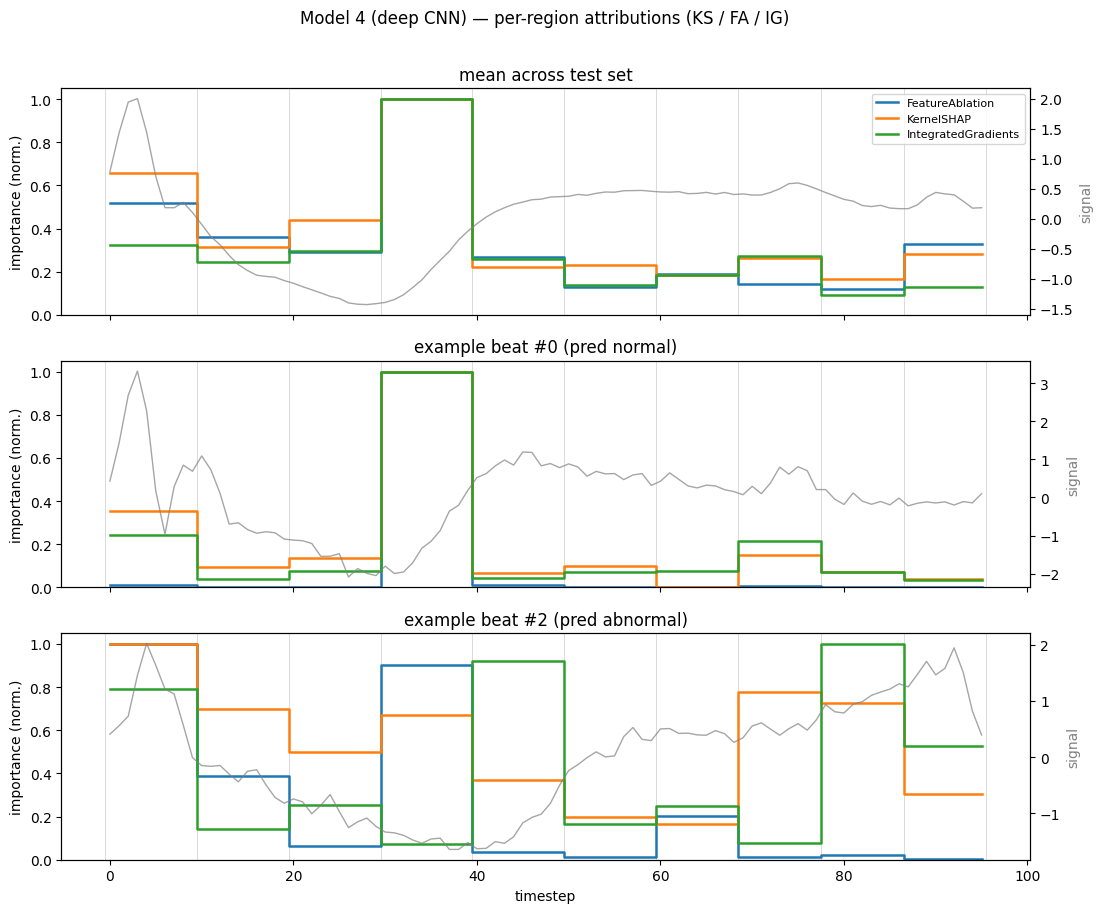

In [6]:
t = np.arange(X_test.shape[1]); to_steps = lambda pr: pr[grid.labels]
preds = predict_proba(X_test).argmax(1)
idx_norm, idx_abn = int(np.where(preds==1)[0][0]), int(np.where(preds==0)[0][0])
def norm(a): return np.abs(a)/np.abs(a).max()
rows = [("mean across test set", X_test.mean(0), prof),
        (f"example beat #{idx_norm} (pred normal)", X_test[idx_norm],
            {"FeatureAblation":norm(FA[idx_norm]),"KernelSHAP":norm(KS[idx_norm]),"IntegratedGradients":norm(IG[idx_norm])}),
        (f"example beat #{idx_abn} (pred abnormal)", X_test[idx_abn],
            {"FeatureAblation":norm(FA[idx_abn]),"KernelSHAP":norm(KS[idx_abn]),"IntegratedGradients":norm(IG[idx_abn])})]
colors={"FeatureAblation":"C0","KernelSHAP":"C1","IntegratedGradients":"C2"}
fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True)
for ax,(title,sig,profs) in zip(axes,rows):
    for b in np.append(grid.bounds[:,0],grid.bounds[-1,1]): ax.axvline(b-0.5,color="grey",lw=0.5,alpha=0.4)
    for name,pr in profs.items(): ax.plot(t,to_steps(pr),color=colors[name],lw=1.8,label=name,drawstyle="steps-mid")
    ax.set_ylabel("importance (norm.)"); ax.set_title(title); ax.set_ylim(0,1.05)
    ax2=ax.twinx(); ax2.plot(t,sig,color="0.5",lw=1,alpha=0.7); ax2.set_ylabel("signal",color="0.5")
axes[0].legend(loc="upper right",fontsize=8); axes[-1].set_xlabel("timestep")
fig.suptitle("Model 4 (deep CNN) — per-region attributions (KS / FA / IG)", y=1.01)
fig.tight_layout(); fig.savefig(FIG_DIR / "06_model4_attributions.png", dpi=150, bbox_inches="tight"); plt.show()

### What the attributions say (read against the watch-threads)

**IG is sane on the deep net.** Completeness holds (mean error ~0.002, max ~0.009 — a touch higher than
Models 2–3 but still the Riemann residual, not degeneracy) and it's non-zero in every region. The extra
depth did not break the gradient method — safe to score later.

**THREAD #7 — cross-method agreement: the decline REVERSED.** This is the headline and it is not what
the declining-agreement story predicted. Correlations went **M2 0.98/0.87/0.88 → M3 0.85/0.60/0.78 →
M4 ≈ 0.95/0.92/0.91** — back up to near-Model-2 levels, with FA–IG recovering from 0.60 to ~0.92. So
**agreement is non-monotonic (high → low → high), not a clean monotonically-declining signal.** Model 3
was a *local dip*, not the onset of a trend. Reported plainly because this is the confound-free signal
we most wanted: across three points it does **not** support agreement declining with complexity. (Two
of three CNNs — the shallow and the deep — show strong agreement; only the medium diverged.)

**THREAD — reliance location: still the early-mid zone, no spurious drift.** All three methods now agree
the **peak is region 3** (early-mid, ~timesteps 30–40); region 0 is no longer dominant. **Early-mid
(regions 0–3) carries ~0.63–0.65 of the mass; the flat tail (regions 6–9) only ~0.23.** So despite
overfitting and worse generalisation, Model 4 still relies on the **same discriminative early-mid region**
notebook 01b flagged — it has **not** drifted onto spurious non-discriminative regions (e.g. the flat
tail past timestep 55). That is a genuinely reassuring, honest observation: the capacity-saturating model
didn't start attending to noise. The reliance *peak* did shift within the early zone (region 0 → region 3
from M3→M4, profile correlation ~0.61), but the zone is unchanged.

**THREAD — IG behaviour: converged back.** M2 (agreed on location, more spread) → M3 (diverged, topped
region 3 alone) → **M4 (converged — all three now top region 3, FA–IG ~0.92).** So IG re-aligned with the
deletion methods on the deep model. Combined with #7, the attribution-level picture on M4 is **agreement,
not divergence** — which tempers the M3 "methods diverging" reading.

**Net read (attribution level, pre-scoring).** The deep, overfitting model is, if anything, *easier* for
the methods to agree on than the medium one, and all three point at the genuine early-mid discriminative
region. So the explainability-ceiling signature (declining agreement) does **not** hold across M2–M4 — an
honest negative for that hypothesis at the attribution level. Whether M4's *CMI* drops (confounded with
overfitting) is a separate question for the scoring step.

**Reproducibility.** FeatureAblation & IG deterministic; KernelSHAP seeded (**seed 0**). Sanity passed —
non-degenerate, completeness holds. Ready to score (separately) when you decide how to read the
overfitting-confounded CMI.

## 8. Scoring the attributions — Model 4's CMI row (confounded: complexity ↑ AND generalisation ↓)

We score the three attributions (MoRF/LeRF, 50% stop → DDS → PES → CMI) across all three PMs, plus
**concentration** and the **overfitting gap (+0.14)**. **Interpretive context to keep explicit:** Model
4 is in the capacity-saturating regime — test accuracy *fell* (0.88→0.86), so **complexity increased
and generalisation decreased together.** Any CMI change here is confounded with overfitting and cannot
be attributed to complexity alone (unlike the clean M2→M3 comparison). Reproducibility: KernelSHAP seed
0; FeatureAblation & IG deterministic; attribution baseline matched to the deletion PM.

In [7]:
from harness.xai.deletion_curves import perturbation_curves
from harness.xai.cmi import compute_cmi
from harness.xai.concentration import region_reliance, dataset_concentration

PMS = ["sample_mean", "zero", "laplace"]
attr_fns = {
    "FeatureAblation":     lambda s, pm: feature_ablation(predict_proba, s, grid, method=pm),
    "KernelSHAP":          lambda s, pm: kernel_shap(predict_proba, s, grid, method=pm),
    "IntegratedGradients": lambda s, pm: integrated_gradients(model, s, grid, method=pm),
}
def cmi_from(fn, pm):
    M, L = [], []
    for s in X_test:
        cur = perturbation_curves(predict_proba, s, grid, fn(s, pm), method=pm); M.append(cur["MoRF"]); L.append(cur["LeRF"])
    return compute_cmi(M, L)
cmi = {name: {pm: cmi_from(fn, pm) for pm in PMS} for name, fn in attr_fns.items()}
for name in cmi:
    print(name)
    for pm in PMS:
        r = cmi[name][pm]; print(f"    {pm:12s} CMI={r['CMI']:.3f}  DDS={r['DDS']:+.3f}  PES={r['PES']:+.3f}")
rng = np.random.RandomState(0)
random_cmi = cmi_from(lambda s, pm: rng.rand(grid.n_regions), "zero")["CMI"]
oracle_cmi = cmi_from(lambda s, pm: region_reliance(predict_proba, s, grid, "zero"), "zero")["CMI"]
conc = dataset_concentration(predict_proba, X_test, grid, "zero")
overfit_gap = 1.0 - splits["test"]["accuracy"]
print(f"\ncontrols: random={random_cmi:.3f}  ORACLE(ceiling)={oracle_cmi:.3f}")
print(f"concentration={conc['mean']:.3f}   overfitting gap={overfit_gap:+.3f}   params={n_params:,}")

FeatureAblation
    sample_mean  CMI=0.715  DDS=+0.556  PES=+1.000
    zero         CMI=0.715  DDS=+0.556  PES=+1.000
    laplace      CMI=0.727  DDS=+0.572  PES=+1.000
KernelSHAP
    sample_mean  CMI=0.693  DDS=+0.530  PES=+1.000
    zero         CMI=0.693  DDS=+0.530  PES=+1.000
    laplace      CMI=0.680  DDS=+0.515  PES=+1.000
IntegratedGradients
    sample_mean  CMI=0.622  DDS=+0.460  PES=+0.960
    zero         CMI=0.622  DDS=+0.460  PES=+0.960
    laplace      CMI=0.538  DDS=+0.384  PES=+0.900



controls: random=0.000  ORACLE(ceiling)=0.715
concentration=0.664   overfitting gap=+0.140   params=403,522


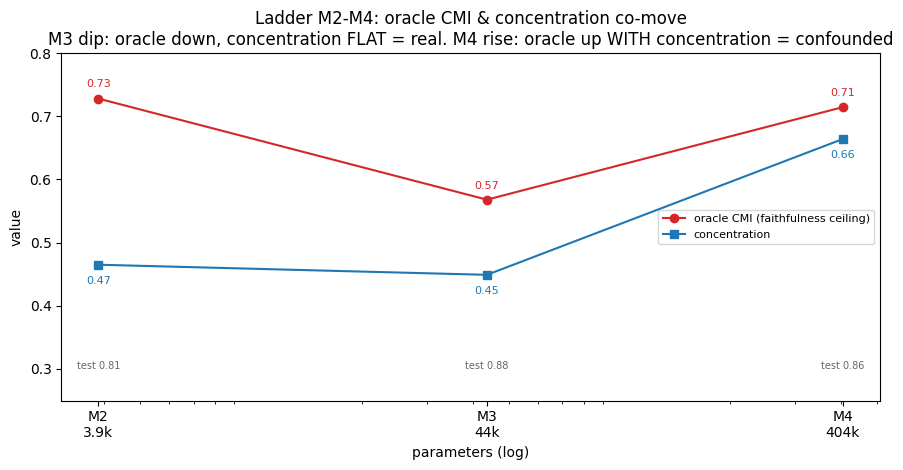

IG (Zero): M2 0.386 -> M3 0.378 -> M4 0.622 | IG PES: 0.56 -> 0.92 -> 0.96 | IG-gap vs FA: 0.342 -> 0.190 -> 0.093


In [8]:
# Ladder decomposition: oracle CMI and concentration co-move -> M4 rise is confounded
params = [3858, 43682, n_params]
oracle = [0.728, 0.568, oracle_cmi]          # M2, M3, M4 (M4 computed)
concn  = [0.465, 0.449, conc["mean"]]
testac = [0.810, 0.880, splits["test"]["accuracy"]]
fig, ax = plt.subplots(figsize=(9, 4.8))
ax.plot(params, oracle, "-o", color="C3", label="oracle CMI (faithfulness ceiling)")
ax.plot(params, concn,  "-s", color="C0", label="concentration")
for x, o, cc, ta in zip(params, oracle, concn, testac):
    ax.annotate(f"{o:.2f}", (x, o), textcoords="offset points", xytext=(0, 8), ha="center", fontsize=8, color="C3")
    ax.annotate(f"{cc:.2f}", (x, cc), textcoords="offset points", xytext=(0, -14), ha="center", fontsize=8, color="C0")
    ax.annotate(f"test {ta:.2f}", (x, 0.30), textcoords="offset points", xytext=(0,0), ha="center", fontsize=7, color="0.4")
ax.set_xscale("log"); ax.set_xlabel("parameters (log)"); ax.set_ylabel("value")
ax.set_xticks(params); ax.set_xticklabels(["M2\n3.9k","M3\n44k","M4\n404k"]); ax.set_ylim(0.25, 0.8)
ax.set_title("Ladder M2-M4: oracle CMI & concentration co-move\n"
             "M3 dip: oracle down, concentration FLAT = real. M4 rise: oracle up WITH concentration = confounded")
ax.legend(fontsize=8)
fig.tight_layout(); fig.savefig(FIG_DIR / "06_model4_ladder.png", dpi=150, bbox_inches="tight"); plt.show()

print("IG (Zero): M2 0.386 -> M3 0.378 -> M4 %.3f | IG PES: 0.56 -> 0.92 -> %.2f | IG-gap vs FA: 0.342 -> 0.190 -> %.3f"
      % (cmi["IntegratedGradients"]["zero"]["CMI"], cmi["IntegratedGradients"]["zero"]["PES"],
         cmi["FeatureAblation"]["zero"]["CMI"]-cmi["IntegratedGradients"]["zero"]["CMI"]))

### Models 1–4 table and the read

| Model | Params | Test | KS | FA | IG | Concentration | Overfit gap |
|---|---|---|---|---|---|---|---|
| 1 — linear *(anchor: freq-band, no IG)* | ~6 | 0.70 | 0.612 | 0.648 | — | 0.24 | ~0.20 |
| 2 — shallow CNN | 3,858 | 0.810 | 0.721 | 0.728 | 0.386 | 0.47 | +0.19 |
| 3 — medium CNN | 43,682 | 0.880 | 0.533 | 0.568 | 0.378 | 0.45 | +0.12 |
| **4 — deep CNN** | 403,522 | 0.860 | **0.693** | **0.715** | **0.622** | **0.66** | +0.14 |

*(M4 full row: FA 0.715/0.715/0.727, KS 0.693/0.693/0.680, IG 0.622/0.622/0.538 for SampleMean/Zero/Laplace; oracle 0.715, random 0.000.)*

**Sanity vs controls — passes.** Real methods (0.54–0.73) sit far above random, which is **0.000** here
(a random ranking gives DDS/PES of opposite sign → CMI's conflicting-signs rule returns 0 — the null
behaving as a null). Nothing near-zero. FA(Zero)=oracle exactly, as always.

**The oracle (ceiling): non-monotonic, and M4's rise is CONFOUNDED.** Oracle went **M2 0.728 → M3 0.568
→ M4 0.715** — it fell at M3 and **recovered at M4**. But the decomposition is the whole point here:
- **M3 dip was REAL** — oracle fell while concentration stayed flat (0.47→0.45), so it wasn't the
  diffuseness confound.
- **M4 rise is CONFOUNDED** — the oracle rose (0.568→0.715) but **concentration jumped with it
  (0.45→0.66)**. A more concentrated model has a higher CMI *ceiling* regardless of faithfulness, so the
  M3→M4 oracle recovery **largely tracks the concentration jump, not a clean faithfulness gain.** On top
  of that, M4 **generalises worse** (overfitting confound). So M4's higher CMI is **doubly confounded
  (more concentrated + overfitting)** and must **not** be read as "the deep model is more faithfully
  explained." (Why the concentration jump? The overfitting deep model latches onto fewer regions — its
  reliance concentrates, notably on region 3 — which is itself a fingerprint of overfitting.)

**Consistency of the CMI story with the confound-free agreement story.** Cross-method agreement was
non-monotonic (0.98/0.87/0.88 → 0.85/0.60/0.78 → 0.95/0.92/0.91) — a **dip at M3, recovery at M4**. The
oracle CMI shows the **same shape** (dip at M3, recovery at M4). So the two signals are **consistent**:
M3 is the outlier on both. The difference is *confounding* — the M3 dip is confirmed real on both (oracle
with flat concentration; agreement is inherently confound-free), whereas M4's CMI recovery is confounded
by concentration/overfitting while its **agreement recovery is confound-free and therefore the more
trustworthy signal** that the methods genuinely re-align on the deep model.

**IG faithfulness: convergence holds and strengthens.** IG(Zero) 0.386 → 0.378 → **0.622**; PES 0.56 →
0.92 → **0.96**; IG-vs-FA gap **0.342 → 0.190 → 0.093** (monotonically narrowing). The "methods
converging in faithfulness" reading from M3 **holds** and matches the attribution-level convergence
(FA–IG 0.92 at M4). Caveat: part of IG's absolute rise at M4 is the same concentration-ceiling confound.

**Honest read — the ladder is non-monotonic, and I am not forcing a trend.** FA CMI across the CNNs runs
**0.728 → 0.568 → 0.715** (down then up); oracle and agreement both dip at M3 and recover at M4. There is
**no clean monotonic complexity effect** in these three points. What survives the confound checks: the
**M3 dip is real** (oracle-with-flat-concentration, plus confound-free agreement), and **M4's CMI recovery
is not a clean faithfulness result** (concentration jump + overfitting). The one clean, confound-free
statement is that **cross-method agreement did not monotonically decline** — a negative for the
explainability-ceiling-via-agreement hypothesis.

> **Single seed per model.** Every model here is one training run with one seed. The non-monotonicity —
> especially the M3 dip — **could be training-run variation rather than a complexity effect.** We do
> **not** resolve that here. The **multi-seed pass (next)** is what will tell us whether the M3 divergence
> is a real property of the medium CNN or an artefact of its particular initialisation/training run.